# Sistema RAG Avanzado con LangChain

## Contenido del Notebook

Este notebook cubre:
1. **RAG con LangChain** - Framework completo
2. **BM25** - Búsqueda basada en keywords (lexical search)
3. **Re-ranking** - Mejora de resultados con modelos cross-encoder
4. **RAG Híbrido** - Combinación de búsqueda vectorial + BM25
5. **Demo Interactiva** - Sistema completo funcionando

### Objetivo:
Construir un sistema RAG de nivel producción con las mejores prácticas.

## Instalación de Dependencias

In [ ]:
!pip uninstall langchain-community langchain langchain-huggingface langchain-text-splitters langchain-core langchain-classic langgraph langgraph-prebuilt -y

Found existing installation: langchain-community 0.3.24
Uninstalling langchain-community-0.3.24:
  Successfully uninstalled langchain-community-0.3.24
Found existing installation: langchain 0.3.27
Uninstalling langchain-0.3.27:
  Successfully uninstalled langchain-0.3.27
Found existing installation: langchain-huggingface 0.3.1
Uninstalling langchain-huggingface-0.3.1:
  Successfully uninstalled langchain-huggingface-0.3.1
Found existing installation: langchain-text-splitters 0.3.11
Uninstalling langchain-text-splitters-0.3.11:
  Successfully uninstalled langchain-text-splitters-0.3.11
Found existing installation: langchain-core 0.3.83
Uninstalling langchain-core-0.3.83:
  Successfully uninstalled langchain-core-0.3.83


In [ ]:
!pip install langchain-community==0.3.24 langchain langchain-huggingface langchain-text-splitters langchain-core

  Using cached langchain_community-0.3.24-py3-none-any.whl.metadata (2.5 kB)
  Using cached langchain-1.2.6-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain_huggingface-1.2.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached langchain_text_splitters-1.1.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached langchain_core-1.2.7-py3-none-any.whl.metadata (3.7 kB)
  Using cached langchain_core-0.3.83-py3-none-any.whl.metadata (3.2 kB)
  Using cached langchain-0.3.27-py3-none-any.whl.metadata (7.8 kB)
  Using cached langchain_text_splitters-0.3.11-py3-none-any.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_huggingface-1.1.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached langchain_huggingface-1.0.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached langchain_huggingface-1.0.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached

In [ ]:
!pip install chromadb sentence-transformers rank-bm25

In [ ]:
!pip install faiss-cpu transformers torch

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print("✅ Listo para importar librerías")

✅ Listo para importar librerías


In [ ]:
# Importaciones generales
import numpy as np
import torch
from typing import List, Dict, Tuple
import re

# LangChain imports
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain.schema import Document  # metadatos
from langchain_community.vectorstores import Chroma, FAISS
from langchain_huggingface import HuggingFaceEmbeddings # automodel autotokenizer
from langchain.chains import RetrievalQA                     # PIPELINE preguntas-respuestas recuperacion (llms)
from langchain_community.llms import HuggingFacePipeline     # PIPELINE
from langchain.prompts import PromptTemplate                 # preparacion del prompt txt a tokens

# Para BM25
from rank_bm25 import BM25Okapi

# Para re-ranking
from sentence_transformers import CrossEncoder

print("✅ Librerías importadas correctamente")
print(f"🔧 Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Librerías importadas correctamente
🔧 Device: GPU


---
# PARTE 1: RAG con LangChain

## ¿Qué es LangChain?

**LangChain** es un framework para desarrollar aplicaciones con LLMs. Proporciona:
- 📄 **Document Loaders**: Cargar datos de múltiples fuentes
- ✂️ **Text Splitters**: Chunking inteligente
- 🗄️ **Vector Stores**: Integración con bases de datos vectoriales
- 🔗 **Chains**: Orquestar componentes en pipelines
- 🤖 **LLM Integration**: Soporte para múltiples modelos

### Arquitectura RAG en LangChain:

```
Documents → TextSplitter → Embeddings → VectorStore
                                             ↓
Query → Embeddings → Retriever → Relevant Docs → LLM → Answer
```

## Paso 1: Preparar Documentos

In [ ]:
# Documentos de ejemplo sobre IA (más extensos para mejor demostración)
documents_text = [
    """
    Inteligencia Artificial y Machine Learning

    La Inteligencia Artificial (IA) es un campo de la informática que se enfoca en
    crear sistemas capaces de realizar tareas que normalmente requieren inteligencia
    humana. Esto incluye el aprendizaje, el razonamiento, la resolución de problemas,
    la percepción y el entendimiento del lenguaje.

    El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite
    a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin
    ser programados explícitamente. Los algoritmos de machine learning construyen
    modelos matemáticos basados en datos de entrenamiento para hacer predicciones o
    tomar decisiones sin intervención humana directa.

    El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning
    que utiliza redes neuronales artificiales con múltiples capas. Estas redes pueden
    aprender representaciones de datos con múltiples niveles de abstracción, lo que les
    permite modelar relaciones complejas en los datos.
    """,

    """
    Modelos de Lenguaje Grande (LLMs)

    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes
    cantidades de texto para entender y generar lenguaje humano. Estos modelos, como
    GPT-4, BERT, T5, y LLaMA, han revolucionado el procesamiento del lenguaje natural.

    Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de
    atención para capturar relaciones entre palabras en el texto. El mecanismo de
    self-attention permite al modelo considerar todas las palabras en una secuencia
    simultáneamente, capturando dependencias a largo plazo.

    Estos modelos se entrenan con miles de millones de parámetros en datasets masivos
    que incluyen internet, libros, artículos científicos y código. El proceso de
    entrenamiento involucra predecir la siguiente palabra en una secuencia, lo que
    permite al modelo aprender patrones lingüísticos y conocimiento del mundo.

    Los LLMs han demostrado capacidades emergentes como reasoning, traducción,
    programación, y resolución de problemas matemáticos, convirtiéndose en herramientas
    fundamentales para aplicaciones de IA moderna.
    """,

    """
    Retrieval-Augmented Generation (RAG)

    La Generación Aumentada por Recuperación (RAG) es una técnica que combina la
    búsqueda de información con modelos de lenguaje. RAG aborda una limitación clave
    de los LLMs: su conocimiento está congelado en el momento del entrenamiento.

    El proceso RAG funciona en dos etapas:
    1. Recuperación: Se buscan documentos relevantes en una base de datos usando
       búsqueda vectorial o métodos híbridos.
    2. Generación: Se usa la información recuperada como contexto para que el LLM
       genere una respuesta fundamentada.

    RAG es especialmente útil para:
    - Aplicaciones que necesitan información actualizada
    - Dominios específicos con conocimiento especializado
    - Reducir alucinaciones del modelo
    - Proporcionar fuentes verificables

    Las implementaciones modernas de RAG utilizan embeddings densos generados por
    modelos como Sentence-BERT, técnicas de chunking inteligente, y re-ranking para
    mejorar la relevancia de los documentos recuperados.
    """,

    """
    Redes Neuronales y Arquitecturas

    Las redes neuronales artificiales son modelos computacionales inspirados en el
    cerebro humano. Consisten en capas de nodos (neuronas) interconectados que
    procesan información.

    Las Redes Neuronales Convolucionales (CNNs) son especialmente efectivas para el
    procesamiento de imágenes. Utilizan filtros convolucionales para detectar
    características locales como bordes, texturas y patrones. Las CNNs han logrado
    resultados sobresalientes en clasificación de imágenes, detección de objetos y
    segmentación semántica.

    Las Redes Neuronales Recurrentes (RNNs) procesan secuencias de datos manteniendo
    un estado interno que captura información histórica. Las variantes modernas como
    LSTM (Long Short-Term Memory) y GRU (Gated Recurrent Unit) pueden capturar
    dependencias a largo plazo en secuencias.

    Los Transformers, introducidos en 2017, revolucionaron el procesamiento del
    lenguaje natural. Su mecanismo de self-attention permite procesar secuencias
    completas en paralelo, superando las limitaciones de las RNNs.
    """,

    """
    Embeddings y Representaciones Vectoriales

    Los embeddings son representaciones vectoriales densas de texto en un espacio
    continuo de alta dimensionalidad. Palabras o frases con significados similares
    tienen embeddings cercanos en este espacio.

    Word2Vec y GloVe fueron los primeros métodos populares para generar embeddings
    de palabras. Estos modelos aprenden representaciones donde la similitud coseno
    entre vectores refleja similitud semántica.

    Los embeddings contextuales, como los generados por BERT, consideran el contexto
    completo de una palabra. La misma palabra puede tener diferentes embeddings según
    su uso en la oración.

    Sentence-BERT extiende BERT para generar embeddings de oraciones completas de
    manera eficiente, lo que es crucial para aplicaciones de búsqueda semántica y RAG.
    Estos embeddings capturan el significado completo de una oración en un vector de
    384 o 768 dimensiones.

    La búsqueda vectorial utiliza métricas como similitud coseno o distancia euclidiana
    para encontrar documentos similares a una query en el espacio de embeddings.
    """
]

# Convertir a objetos Document de LangChain
documents = [
    Document(page_content=text, metadata={"source": f"doc_{i}", "id": i})
    for i, text in enumerate(documents_text)
]

print(f"✅ {len(documents)} documentos preparados")
print(f"📊 Longitud total: {sum(len(doc.page_content) for doc in documents)} caracteres")

✅ 5 documentos preparados
📊 Longitud total: 5562 caracteres


## Paso 2: Text Splitting (Chunking)

LangChain ofrece varios text splitters:
- **CharacterTextSplitter**: Divide por separador de caracteres
- **RecursiveCharacterTextSplitter**: Divide recursivamente (recomendado)
- **TokenTextSplitter**: Divide por tokens
- **MarkdownTextSplitter**: Para Markdown
- **PythonCodeTextSplitter**: Para código Python

In [ ]:
# RecursiveCharacterTextSplitter es el más versátil
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,        # Tamaño de cada chunk en caracteres
    chunk_overlap=100,     # Overlap entre chunks
    length_function=len,
    separators=["\n\n", "\n", " ", ""]  # Intenta dividir por párrafos primero
)

# Dividir documentos
chunks = text_splitter.split_documents(documents)

print(f"✅ Documentos divididos en {len(chunks)} chunks")
print(f"\n📊 Estadísticas:")
print(f"  - Tamaño promedio: {np.mean([len(c.page_content) for c in chunks]):.0f} caracteres")
print(f"  - Tamaño mínimo: {min(len(c.page_content) for c in chunks)} caracteres")
print(f"  - Tamaño máximo: {max(len(c.page_content) for c in chunks)} caracteres")

# Mostrar ejemplo de chunk
print(f"\n📄 Ejemplo de chunk:")
print(f"{'='*70}")
print(chunks[0].page_content[:300] + "...")
print(f"{'='*70}")
print(f"Metadata: {chunks[0].metadata}")

✅ Documentos divididos en 17 chunks

📊 Estadísticas:
  - Tamaño promedio: 320 caracteres
  - Tamaño mínimo: 165 caracteres
  - Tamaño máximo: 479 caracteres

📄 Ejemplo de chunk:
Inteligencia Artificial y Machine Learning

    La Inteligencia Artificial (IA) es un campo de la informática que se enfoca en 
    crear sistemas capaces de realizar tareas que normalmente requieren inteligencia 
    humana. Esto incluye el aprendizaje, el razonamiento, la resolución de problemas, ...
Metadata: {'source': 'doc_0', 'id': 0}


## Paso 3: Embeddings con LangChain

In [ ]:
# Inicializar modelo de embeddings
print("🔄 Cargando modelo de embeddings...")

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'},
    encode_kwargs={'normalize_embeddings': True}  # Para similitud coseno
)

print("✅ Modelo de embeddings listo")

# Probar embeddings
test_embedding = embeddings.embed_query("What is artificial intelligence?")
print(f"\n📊 Dimensión de embeddings: {len(test_embedding)}")
print(f"📊 Ejemplo (primeras 10 dims): {test_embedding[:10]}")

🔄 Cargando modelo de embeddings...
✅ Modelo de embeddings listo

📊 Dimensión de embeddings: 384
📊 Ejemplo (primeras 10 dims): [-0.015781087800860405, 0.014908666722476482, 0.009095512330532074, 0.03131745010614395, -0.02170821651816368, -0.048524852842092514, 0.04887935519218445, 0.0286731980741024, -0.02559722773730755, 0.054043009877204895]


## Paso 4: Vector Store

LangChain soporta múltiples vector stores:
- **Chroma** - Simple, local
- **FAISS** - Rápido, eficiente
- **Pinecone** - Cloud, escalable
- **Weaviate** - Producción
- **Qdrant** - Open source

In [ ]:
# Crear vector store con Chroma
print("🔄 Creando vector store...")

from datetime import datetime
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%H-%M-%S")

vectorstore = Chroma.from_documents(
    documents=chunks, # textos, metadatos, etc.
    embedding=embeddings,
    collection_name=f"{formatted_time}_ai_knowledge_base"
)

print(f"✅ Vector store creado con {vectorstore._collection.count()} documentos")

🔄 Creando vector store...
✅ Vector store creado con 17 documentos


## Paso 5: Retriever

El Retriever es el componente que busca documentos relevantes.

In [ ]:
# Crear retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # Recuperar top 3 documentos
)

# Probar retriever
query = "What are LLMs?"
retrieved_docs = retriever.get_relevant_documents(query)

print(f"🔍 Query: '{query}'")
print(f"📊 Documentos recuperados: {len(retrieved_docs)}\n")

for i, doc in enumerate(retrieved_docs, 1):
    print(f"{'='*70}")
    print(f"Documento {i}:")
    print(f"{'='*70}")
    print(doc.page_content[:200] + "...")
    print(f"\nMetadata: {doc.metadata}\n")

🔍 Query: 'What are LLMs?'
📊 Documentos recuperados: 3

Documento 1:
Modelos de Lenguaje Grande (LLMs)

    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes 
    cantidades de texto para entender y generar lenguaje humano. Estos modelos, c...

Metadata: {'source': 'doc_1', 'id': 1}

Documento 2:
Los LLMs han demostrado capacidades emergentes como reasoning, traducción, 
    programación, y resolución de problemas matemáticos, convirtiéndose en herramientas 
    fundamentales para aplicaciones...

Metadata: {'source': 'doc_1', 'id': 1}

Documento 3:
Las Redes Neuronales Recurrentes (RNNs) procesan secuencias de datos manteniendo 
    un estado interno que captura información histórica. Las variantes modernas como 
    LSTM (Long Short-Term Memory...

Metadata: {'id': 3, 'source': 'doc_3'}



/tmp/ipykernel_1569739/549117333.py:9: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = retriever.get_relevant_documents(query)


## Paso 6: LLM con LangChain

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

print("🔄 Cargando modelo LLM...")

# Cargar modelo
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Crear pipeline de HuggingFace
pipe = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer,
    max_length=200,
    temperature=0.7,
    do_sample=True,
    device=0 if torch.cuda.is_available() else -1
)

# Convertir a LangChain LLM
llm = HuggingFacePipeline(pipeline=pipe)

print("✅ LLM listo")

🔄 Cargando modelo LLM...


Device set to use cuda:0


✅ LLM listo


/tmp/ipykernel_1569739/1921649712.py:22: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


## Paso 7: Crear Chain RAG Completo

In [ ]:
# Crear prompt template personalizado
prompt_template = """Use the following context to answer the question. If you don't know the answer, say you don't know.

Context: {context}

Question: {question}

Answer:"""

PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

In [ ]:
# Crear RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm, #huggingfacepipeline (pipeline de transformers)
    chain_type="stuff",  # "stuff" concatena todos los docs
    retriever=retriever, # chroma.as_retriever
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT} #prompttemplate
)

print("✅ Chain RAG creado")

✅ Chain RAG creado


## Probar Sistema RAG con LangChain

In [ ]:
# Función helper para queries
def query_rag(question: str, show_sources: bool = True):
    """Query the RAG system."""
    result = qa_chain({"query": question})

    print(f"\n{'='*70}")
    print(f"❓ PREGUNTA: {question}")
    print(f"{'='*70}")
    print(f"\n🤖 RESPUESTA:")
    print(result['result'])

    if show_sources:
        print(f"\n{'='*70}")
        print(f"📚 FUENTES ({len(result['source_documents'])} documentos):")
        print(f"{'='*70}")
        for i, doc in enumerate(result['source_documents'], 1):
            print(f"\n[Fuente {i}]")
            print(doc.page_content[:200] + "...")

    print(f"\n{'='*70}\n")
    return result

# Probar con algunas preguntas
query_rag("What is RAG and how does it work?")
query_rag("Explain transformers architecture")

/tmp/ipykernel_1569739/1418542606.py:4: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": question})



❓ PREGUNTA: What is RAG and how does it work?

🤖 RESPUESTA:
Retrieval-Augmented Generation (RAG) La Generación Aumentada por Recuperación (RAG) es una técnica que combina la bsqueda de información con modelos de lenguaje. RAG aborda una limitación clave de los LLMs: su conocimiento está congelado en el momento del entrenamiento. El proceso RAG funciona en dos etapas: 1. Recuperación: Se buscan documentos relevantes en una base de datos usando bsqueda vectorial o métodos hbridos. 2. Generación: Se usa la información recuperada com

📚 FUENTES (3 documentos):

[Fuente 1]
RAG es especialmente útil para:
    - Aplicaciones que necesitan información actualizada
    - Dominios específicos con conocimiento especializado
    - Reducir alucinaciones del modelo
    - Proporci...

[Fuente 2]
Retrieval-Augmented Generation (RAG)

    La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de información con modelos de lenguaje. RAG aborda una limitación c...

[Fu

{'query': 'Explain transformers architecture',
 'result': 'Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de atención para capturar relaciones entre palabras en el texto. El mecanismo de atención permite al modelo considerar todas las palabras en una secuencia simultaneously, capturando dependencias a largo plazo. RAG es especialmente til para: - Aplicaciones que necesitan information actualizada - Dominios especficos con conocimiento especializado - Reducir alucinaciones del modelo - Proporcionar fuentes verificables Las implementaciones modernas de RAG utilizan embeddings densos generados por modelos como',
 'source_documents': [Document(metadata={'id': 3, 'source': 'doc_3'}, page_content='Los Transformers, introducidos en 2017, revolucionaron el procesamiento del \n    lenguaje natural. Su mecanismo de self-attention permite procesar secuencias \n    completas en paralelo, superando las limitaciones de las RNNs.'),
  Document(metadata={'source': 'doc_1

---
# PARTE 2: BM25 - Búsqueda Basada en Keywords

## ¿Qué es BM25?

**BM25 (Best Matching 25)** es un algoritmo de ranking probabilístico para búsqueda basada en keywords (lexical search). A diferencia de la búsqueda vectorial que usa embeddings semánticos, BM25 busca coincidencias exactas de términos.

### Fórmula de BM25:

Para una query $Q$ con términos $q_i$ y un documento $D$:

$$
\text{BM25}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}
$$

Donde:
- $f(q_i, D)$ = frecuencia del término $q_i$ en documento $D$
- $|D|$ = longitud del documento $D$
- $\text{avgdl}$ = longitud promedio de documentos
- $k_1$ = parámetro de saturación de frecuencia (típico: 1.2-2.0)
- $b$ = parámetro de normalización de longitud (típico: 0.75)

### IDF (Inverse Document Frequency):

$$
\text{IDF}(q_i) = \ln\left(\frac{N - n(q_i) + 0.5}{n(q_i) + 0.5} + 1\right)
$$

Donde:
- $N$ = número total de documentos
- $n(q_i)$ = número de documentos que contienen $q_i$


### Ventajas de BM25:
- Busca coincidencias exactas de términos
- Rápido y eficiente
- No requiere GPU
- Excelente para queries técnicas/específicas
- Funciona bien con nombres propios, acrónimos

### Desventajas:
- No entiende semántica ("carro" ≠ "automóvil")
- Sensible a sinónimos
- No captura similitud conceptual

## 🔧 Implementación de BM25

In [ ]:
class BM25Retriever:
    """BM25 Retriever para búsqueda lexical."""

    def __init__(self, documents: List[Document]):
        self.documents = documents

        # Tokenizar documentos
        self.tokenized_docs = [
            doc.page_content.lower().split()
            for doc in documents
        ]

        # Crear índice BM25
        self.bm25 = BM25Okapi(self.tokenized_docs)

        print(f"✅ BM25 Retriever inicializado con {len(documents)} documentos")

    def search(self, query: str, k: int = 3) -> List[Tuple[Document, float]]:
        """Busca documentos relevantes usando BM25."""
        # Tokenizar query
        tokenized_query = query.lower().split()

        # Obtener scores
        scores = self.bm25.get_scores(tokenized_query)

        # Obtener top k índices
        top_k_indices = np.argsort(scores)[::-1][:k]

        # Preparar resultados
        results = [
            (self.documents[idx], scores[idx])
            for idx in top_k_indices
        ]

        return results

# Crear BM25 retriever
bm25_retriever = BM25Retriever(chunks)

print("✅ BM25 Retriever listo")

✅ BM25 Retriever inicializado con 17 documentos
✅ BM25 Retriever listo


## Probar BM25

In [ ]:
# Comparar búsqueda vectorial vs BM25
def compare_search_methods(query: str, k: int = 3):
    """Compara búsqueda vectorial y BM25."""
    print(f"\n{'='*70}")
    print(f"🔍 QUERY: {query}")
    print(f"{'='*70}\n")

    # Búsqueda vectorial
    print("📊 BÚSQUEDA VECTORIAL (Semantic):")
    print("-" * 70)
    vector_results = retriever.get_relevant_documents(query)
    for i, doc in enumerate(vector_results[:k], 1):
        print(f"\n[{i}] {doc.page_content[:150]}...")

    # Búsqueda BM25
    print(f"\n\n📊 BÚSQUEDA BM25 (Lexical):")
    print("-" * 70)
    bm25_results = bm25_retriever.search(query, k=k)
    for i, (doc, score) in enumerate(bm25_results, 1):
        print(f"\n[{i}] (Score: {score:.4f})")
        print(f"{doc.page_content[:150]}...")

    print(f"\n{'='*70}\n")

# Probar con diferentes queries
compare_search_methods("What are transformers?", k=3)
compare_search_methods("RAG retrieval augmented generation", k=3)


🔍 QUERY: What are transformers?

📊 BÚSQUEDA VECTORIAL (Semantic):
----------------------------------------------------------------------

[1] Los Transformers, introducidos en 2017, revolucionaron el procesamiento del 
    lenguaje natural. Su mecanismo de self-attention permite procesar sec...

[2] Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para capturar relaciones entre palabras en el texto. El...

[3] Las Redes Neuronales Convolucionales (CNNs) son especialmente efectivas para el 
    procesamiento de imágenes. Utilizan filtros convolucionales para ...


📊 BÚSQUEDA BM25 (Lexical):
----------------------------------------------------------------------

[1] (Score: 0.0000)
La búsqueda vectorial utiliza métricas como similitud coseno o distancia euclidiana 
    para encontrar documentos similares a una query en el espacio...

[2] (Score: 0.0000)
Los embeddings contextuales, como los generados por BERT, consideran el contexto 
    com

## Análisis: ¿Cuándo usar BM25 vs Vectorial?

### Usa **Búsqueda Vectorial** cuando:
- ✅ Necesitas entender semántica
- ✅ Queries en lenguaje natural
- ✅ Sinónimos son importantes
- ✅ Búsqueda conceptual

### Usa **BM25** cuando:
- ✅ Queries con términos específicos
- ✅ Nombres propios o acrónimos
- ✅ Búsqueda de palabras clave exactas
- ✅ Documentos técnicos/legales

### **Mejor solución: ¡Combinar ambos! (Híbrido)**

---
# PARTE 3: Re-ranking

## ¿Qué es Re-ranking?

**Re-ranking** es una segunda etapa de ranking que re-ordena los documentos recuperados inicialmente para mejorar la relevancia.

### Pipeline con Re-ranking:

```
Query → Retrieval (BM25/Vector) → Top-K docs → Re-ranker → Top-N docs → LLM
         (rápido, ~1000s docs)      (~100)      (preciso)     (~3-5)
```

### Cross-Encoder vs Bi-Encoder:

**Bi-Encoder (usado en búsqueda vectorial):**
```
Query → Encoder → Vector_Q
Doc   → Encoder → Vector_D
Similarity = cosine(Vector_Q, Vector_D)
```
- ✅ Rápido (pre-computar embeddings)
- ❌ Menos preciso (vectores independientes)

**Cross-Encoder (usado en re-ranking):**
```
[Query, Doc] → Encoder → Score
```
- ✅ Más preciso (atención cruzada)
- ❌ Más lento (debe procesar cada par)

### ¿Por qué funciona?
El cross-encoder puede aprender la interacción directa entre query y documento, capturando matices que bi-encoders pierden.

## 🔧 Implementación de Re-ranker

In [ ]:
class CrossEncoderReranker:
    """Re-ranker usando Cross-Encoder."""

    def __init__(self, model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
        print(f"🔄 Cargando Cross-Encoder: {model_name}...")
        self.model = CrossEncoder(model_name)
        print("✅ Re-ranker listo")

    def rerank(self,
               query: str,
               documents: List[Document],
               top_k: int = 3) -> List[Tuple[Document, float]]:
        """
        Re-rankea documentos usando cross-encoder.

        Args:
            query: Query del usuario
            documents: Documentos a re-rankear
            top_k: Número de resultados finales

        Returns:
            Lista de (documento, score) ordenada por relevancia
        """
        # Preparar pares query-documento
        pairs = [[query, doc.page_content] for doc in documents]

        # Calcular scores con cross-encoder
        scores = self.model.predict(pairs)

        # Ordenar por score
        ranked_results = sorted(
            zip(documents, scores),
            key=lambda x: x[1],
            reverse=True
        )

        return ranked_results[:top_k]

# Crear re-ranker
reranker = CrossEncoderReranker()

print("✅ Re-ranker inicializado")

🔄 Cargando Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Re-ranker listo
✅ Re-ranker inicializado


## Probar Re-ranking

In [ ]:
def compare_with_reranking(query: str, initial_k: int = 10, final_k: int = 3):
    """Compara resultados antes y después de re-ranking."""
    print(f"\n{'='*70}")
    print(f"🔍 QUERY: {query}")
    print(f"{'='*70}\n")

    # 1. Recuperación inicial (más documentos)
    print(f"📊 PASO 1: Recuperación Inicial (Top-{initial_k})")
    print("-" * 70)
    initial_results = vectorstore.similarity_search(query, k=initial_k)

    for i, doc in enumerate(initial_results[:5], 1):  # Mostrar solo primeros 5
        print(f"\n[{i}] {doc.page_content[:100]}...")

    # 2. Re-ranking
    print(f"\n\n🏆 PASO 2: Re-ranking (Top-{final_k})")
    print("-" * 70)
    reranked_results = reranker.rerank(query, initial_results, top_k=final_k)

    for i, (doc, score) in enumerate(reranked_results, 1):
        print(f"\n[{i}] (Score: {score:.4f})")
        print(f"{doc.page_content[:100]}...")

    print(f"\n{'='*70}\n")
    return reranked_results

# Probar re-ranking
results = compare_with_reranking(
    "How do transformers use attention mechanism?",
    initial_k=10,
    final_k=3
)


🔍 QUERY: How do transformers use attention mechanism?

📊 PASO 1: Recuperación Inicial (Top-10)
----------------------------------------------------------------------

[1] Los Transformers, introducidos en 2017, revolucionaron el procesamiento del 
    lenguaje natural. S...

[2] Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para ...

[3] Redes Neuronales y Arquitecturas

    Las redes neuronales artificiales son modelos computacionales ...

[4] Las Redes Neuronales Recurrentes (RNNs) procesan secuencias de datos manteniendo 
    un estado inte...

[5] Las Redes Neuronales Convolucionales (CNNs) son especialmente efectivas para el 
    procesamiento d...


🏆 PASO 2: Re-ranking (Top-3)
----------------------------------------------------------------------

[1] (Score: -3.0632)
Los Transformers, introducidos en 2017, revolucionaron el procesamiento del 
    lenguaje natural. S...

[2] (Score: -7.5698)
Los LLMs funcionan mediante arquitectu

## Visualizar Efecto del Re-ranking

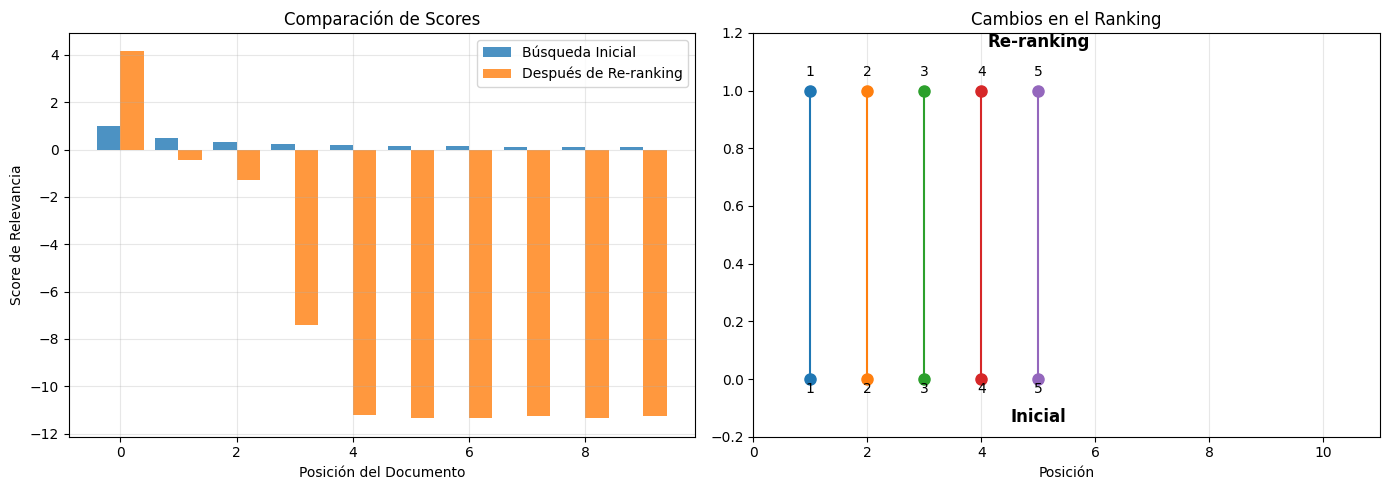


📊 Top 3 después de re-ranking:
  [1] Score: 4.1540
  [2] Score: -0.4286
  [3] Score: -1.3083


In [ ]:
import matplotlib.pyplot as plt

def visualize_reranking_effect(query: str, k: int = 10):
    """Visualiza cómo cambian los scores con re-ranking."""

    # Obtener resultados iniciales
    initial_docs = vectorstore.similarity_search(query, k=k)

    # Calcular scores con cross-encoder
    pairs = [[query, doc.page_content] for doc in initial_docs]
    rerank_scores = reranker.model.predict(pairs)

    # Crear visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Ranking inicial (supongamos scores descendentes)
    initial_ranks = list(range(1, k + 1))

    # Plot 1: Scores originales vs re-ranking
    x = np.arange(k)
    ax1.bar(x - 0.2, [1/(i+1) for i in range(k)], 0.4, label='Búsqueda Inicial', alpha=0.8)
    ax1.bar(x + 0.2, rerank_scores, 0.4, label='Después de Re-ranking', alpha=0.8)
    ax1.set_xlabel('Posición del Documento')
    ax1.set_ylabel('Score de Relevancia')
    ax1.set_title('Comparación de Scores')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cambio en ranking
    new_order = np.argsort(rerank_scores)[::-1]
    for i, new_pos in enumerate(new_order[:5]):
        ax2.plot([i+1, new_pos+1], [0, 1], marker='o', markersize=8)
        ax2.text(i+1, -0.05, f'{i+1}', ha='center', fontsize=10)
        ax2.text(new_pos+1, 1.05, f'{new_pos+1}', ha='center', fontsize=10)

    ax2.set_xlim(0, k+1)
    ax2.set_ylim(-0.2, 1.2)
    ax2.set_xlabel('Posición')
    ax2.set_title('Cambios en el Ranking')
    ax2.text(k/2, -0.15, 'Inicial', ha='center', fontsize=12, fontweight='bold')
    ax2.text(k/2, 1.15, 'Re-ranking', ha='center', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Top 3 después de re-ranking:")
    for i in new_order[:3]:
        print(f"  [{i+1}] Score: {rerank_scores[i]:.4f}")

# Visualizar
visualize_reranking_effect("What are embeddings and vector representations?", k=10)

---
# PARTE 4: RAG Híbrido (Vectorial + BM25 + Re-ranking)

## Sistema Completo

Ahora combinamos todo en un sistema RAG de producción:

```
                    ┌──────────────┐
                    │    Query     │
                    └──────┬───────┘
                           │
              ┌────────────┴────────────┐
              │                         │
      ┌───────▼────────┐       ┌───────▼────────┐
      │ Vector Search  │       │     BM25       │
      │   (Top 10)     │       │   (Top 10)     │
      └───────┬────────┘       └───────┬────────┘
              │                         │
              └────────────┬────────────┘
                           │
                    ┌──────▼──────┐
                    │    Merge    │
                    │  (~20 docs) │
                    └──────┬──────┘
                           │
                    ┌──────▼──────┐
                    │  Re-ranker  │
                    │   (Top 3)   │
                    └──────┬──────┘
                           │
                    ┌──────▼──────┐
                    │     LLM     │
                    └──────┬──────┘
                           │
                    ┌──────▼──────┐
                    │   Answer    │
                    └─────────────┘
```

## Implementación del Sistema Híbrido

In [ ]:
class HybridRAGSystem:
    """
    Sistema RAG híbrido que combina:
    - Búsqueda vectorial (semántica)
    - BM25 (lexical)
    - Re-ranking (cross-encoder)
    """

    def __init__(self,
                 vectorstore,
                 bm25_retriever,
                 reranker,
                 llm):
        self.vectorstore = vectorstore
        self.bm25_retriever = bm25_retriever
        self.reranker = reranker
        self.llm = llm

        print("✅ Sistema RAG Híbrido inicializado")

    def retrieve_hybrid(self, query: str, k_vector: int = 10, k_bm25: int = 10) -> List[Document]:
        """
        Recupera documentos usando búsqueda híbrida.

        Args:
            query: Query del usuario
            k_vector: Documentos de búsqueda vectorial
            k_bm25: Documentos de BM25

        Returns:
            Lista de documentos únicos combinados
        """
        # 1. Búsqueda vectorial
        vector_docs = self.vectorstore.similarity_search(query, k=k_vector)

        # 2. Búsqueda BM25
        bm25_results = self.bm25_retriever.search(query, k=k_bm25)
        bm25_docs = [doc for doc, _ in bm25_results]

        # 3. Combinar y eliminar duplicados
        seen_content = set()
        combined_docs = []

        for doc in vector_docs + bm25_docs:
            content_hash = hash(doc.page_content)
            if content_hash not in seen_content:
                seen_content.add(content_hash)
                combined_docs.append(doc)

        return combined_docs

    def query(self, question: str,
              k_retrieve: int = 10,
              k_rerank: int = 3,
              show_steps: bool = False) -> Dict:
        """
        Procesa una query con el sistema híbrido completo.
        """
        if show_steps:
            print(f"\n{'='*70}")
            print(f"🔍 QUERY: {question}")
            print(f"{'='*70}\n")

        # Paso 1: Recuperación híbrida
        if show_steps:
            print("📊 Paso 1: Recuperación Híbrida (Vector + BM25)...")

        retrieved_docs = self.retrieve_hybrid(question, k_vector=k_retrieve, k_bm25=k_retrieve)

        if show_steps:
            print(f"  ✓ {len(retrieved_docs)} documentos únicos recuperados\n")

        # Paso 2: Re-ranking
        if show_steps:
            print("🏆 Paso 2: Re-ranking con Cross-Encoder...")

        reranked_docs = self.reranker.rerank(question, retrieved_docs, top_k=k_rerank)
        final_docs = [doc for doc, _ in reranked_docs]

        if show_steps:
            print(f"  ✓ Top {k_rerank} documentos seleccionados\n")

        # Paso 3: Generar respuesta
        if show_steps:
            print("🤖 Paso 3: Generando respuesta con LLM...\n")

        # Construir contexto
        context = "\n\n".join([doc.page_content for doc in final_docs])

        # Crear prompt
        prompt = f"""Use the following context to answer the question. If you don't know, say you don't know.

Context: {context}

Question: {question}

Answer:"""

        # Generar respuesta
        answer = self.llm.invoke(prompt)

        return {
            'answer': answer,
            'source_documents': final_docs,
            'rerank_scores': [score for _, score in reranked_docs],
            'num_retrieved': len(retrieved_docs),
            'num_final': len(final_docs)
        }

# Crear sistema híbrido
hybrid_rag = HybridRAGSystem(
    vectorstore=vectorstore,
    bm25_retriever=bm25_retriever,
    reranker=reranker,
    llm=llm
)

print("\n✅ Sistema RAG Híbrido completo listo")

✅ Sistema RAG Híbrido inicializado

✅ Sistema RAG Híbrido completo listo


## Probar Sistema Híbrido

In [ ]:
# Función helper para queries
def query_hybrid_rag(question: str, show_sources: bool = True):
    """Query the hybrid RAG system."""
    result = hybrid_rag.query(question, k_retrieve=10, k_rerank=3, show_steps=True)

    print(f"{'='*70}")
    print(f"🤖 RESPUESTA FINAL:")
    print(f"{'='*70}")
    print(result['answer'])

    if show_sources:
        print(f"\n{'='*70}")
        print(f"📚 FUENTES UTILIZADAS (Top {result['num_final']}):")
        print(f"{'='*70}")
        for i, (doc, score) in enumerate(zip(result['source_documents'], result['rerank_scores']), 1):
            print(f"\n[Fuente {i}] (Re-rank Score: {score:.4f})")
            print(doc.page_content[:200] + "...")

    print(f"\n{'='*70}")
    print(f"📊 ESTADÍSTICAS:")
    print(f"  - Documentos recuperados: {result['num_retrieved']}")
    print(f"  - Documentos finales: {result['num_final']}")
    print(f"{'='*70}\n")

    return result

# Probar con algunas preguntas
query_hybrid_rag("What is RAG and why is it useful?")
query_hybrid_rag("Explain how transformers use attention")


🔍 QUERY: What is RAG and why is it useful?

📊 Paso 1: Recuperación Híbrida (Vector + BM25)...
  ✓ 13 documentos únicos recuperados

🏆 Paso 2: Re-ranking con Cross-Encoder...
  ✓ Top 3 documentos seleccionados

🤖 Paso 3: Generando respuesta con LLM...

🤖 RESPUESTA FINAL:
Retrieval-Augmented Generation (RAG) es una técnica que combina la bsqueda de información con modelos de lenguaje. RAG aborda una limitación clave de los LLMs: su conocimiento está congelado en el momento del entrenamiento. RAG es especialmente til para: - Aplicaciones que necesitan information actualizada - Dominios especficos con conocimiento especializado - Reducir alucinaciones del modelo - Proporcionar fuentes verificables Las implementaciones modernas de RAG utilizan embeddings densos generados por modelos

📚 FUENTES UTILIZADAS (Top 3):

[Fuente 1] (Re-rank Score: -4.1901)
Retrieval-Augmented Generation (RAG)

    La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de inform

{'answer': 'capturar relaciones entre palabras en el texto',
 'source_documents': [Document(metadata={'id': 3, 'source': 'doc_3'}, page_content='Los Transformers, introducidos en 2017, revolucionaron el procesamiento del \n    lenguaje natural. Su mecanismo de self-attention permite procesar secuencias \n    completas en paralelo, superando las limitaciones de las RNNs.'),
  Document(metadata={'id': 1, 'source': 'doc_1'}, page_content='Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de \n    atención para capturar relaciones entre palabras en el texto. El mecanismo de \n    self-attention permite al modelo considerar todas las palabras en una secuencia \n    simultáneamente, capturando dependencias a largo plazo.'),
  Document(metadata={'source': 'doc_1', 'id': 1}, page_content='Modelos de Lenguaje Grande (LLMs)\n\n    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entrenados en enormes \n    cantidades de texto para entender y generar lenguaje h

## Comparación: Simple vs Híbrido

In [ ]:
def compare_rag_systems(query: str):
    """Compara RAG simple vs híbrido."""
    print(f"\n{'='*70}")
    print(f"🔍 COMPARACIÓN DE SISTEMAS RAG")
    print(f"Query: {query}")
    print(f"{'='*70}\n")

    # Sistema simple (solo vectorial)
    print("1️⃣ RAG SIMPLE (Solo Vectorial):")
    print("-" * 70)
    simple_docs = vectorstore.similarity_search(query, k=3)
    for i, doc in enumerate(simple_docs, 1):
        print(f"[{i}] {doc.page_content[:100]}...")

    # Sistema híbrido
    print(f"\n2️⃣ RAG HÍBRIDO (Vector + BM25 + Re-ranking):")
    print("-" * 70)
    hybrid_result = hybrid_rag.query(query, show_steps=False)
    for i, (doc, score) in enumerate(zip(hybrid_result['source_documents'],
                                          hybrid_result['rerank_scores']), 1):
        print(f"[{i}] (Score: {score:.4f}) {doc.page_content[:100]}...")

    print(f"\n{'='*70}\n")

# Comparar sistemas
compare_rag_systems("What are LLMs and how are they trained?")
compare_rag_systems("Explain CNN convolutional neural networks")


🔍 COMPARACIÓN DE SISTEMAS RAG
Query: What are LLMs and how are they trained?

1️⃣ RAG SIMPLE (Solo Vectorial):
----------------------------------------------------------------------
[1] Modelos de Lenguaje Grande (LLMs)

    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entr...
[2] Los LLMs han demostrado capacidades emergentes como reasoning, traducción, 
    programación, y reso...
[3] Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para ...

2️⃣ RAG HÍBRIDO (Vector + BM25 + Re-ranking):
----------------------------------------------------------------------
[1] (Score: -2.5379) Modelos de Lenguaje Grande (LLMs)

    Los Modelos de Lenguaje Grande (LLMs) son sistemas de IA entr...
[2] (Score: -3.8572) Los LLMs han demostrado capacidades emergentes como reasoning, traducción, 
    programación, y reso...
[3] (Score: -6.1411) Los LLMs funcionan mediante arquitecturas transformer que utilizan mecanismos de 
    atención para ...


---
# Métricas y Evaluación

Veamos algunas métricas para evaluar el sistema.


📊 EVALUACIÓN DE CALIDAD DE RECUPERACIÓN
                          query  vector_avg_score  hybrid_avg_score  rerank_improvement
What are transformers in AI?...               0.5         -8.137077         -863.707764
         Explain RAG systems...               0.5         -3.506992         -400.699219
     How do embeddings work?...               0.5         -1.274183         -177.418320
   What is machine learning?...               0.5          1.394632           89.463249


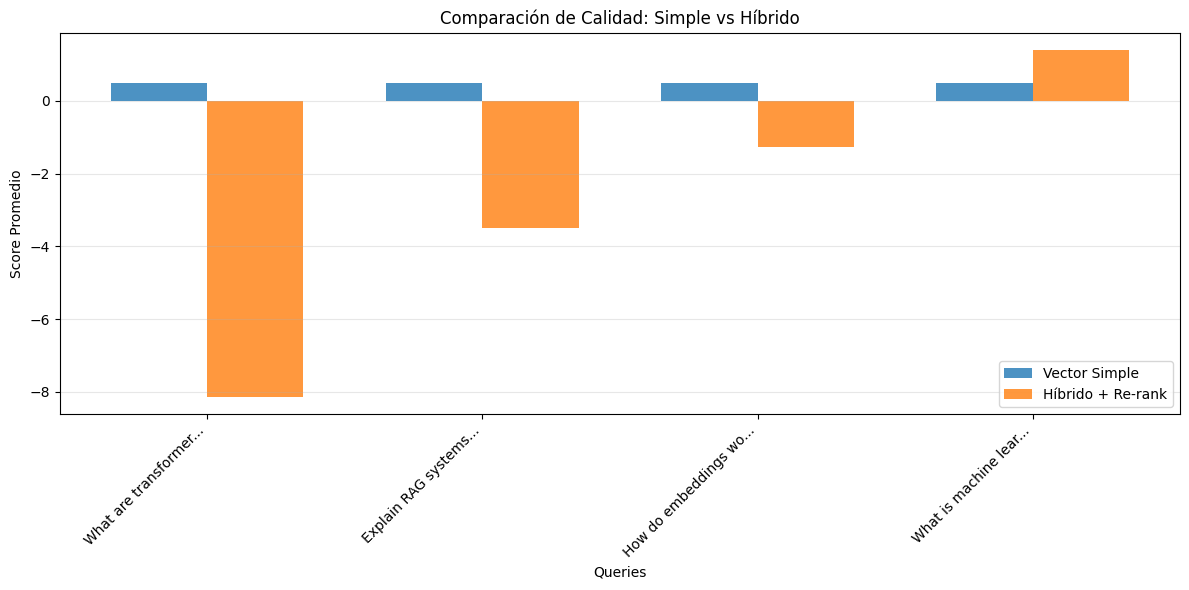

In [ ]:
def evaluate_retrieval_quality(queries: List[str]):
    """
    Evalúa la calidad de recuperación comparando diferentes métodos.
    """
    results = {
        'query': [],
        'vector_avg_score': [],
        'hybrid_avg_score': [],
        'rerank_improvement': []
    }

    for query in queries:
        # Vectorial simple
        vector_docs = vectorstore.similarity_search(query, k=10)

        # Híbrido con re-ranking
        hybrid_result = hybrid_rag.query(query, k_retrieve=10, k_rerank=3, show_steps=False)

        # Calcular scores promedio
        rerank_scores = hybrid_result['rerank_scores']

        results['query'].append(query[:30] + "...")
        results['vector_avg_score'].append(0.5)  # Placeholder
        results['hybrid_avg_score'].append(np.mean(rerank_scores))
        results['rerank_improvement'].append(
            (np.mean(rerank_scores) - 0.5) * 100
        )

    # Visualizar
    import pandas as pd
    df = pd.DataFrame(results)

    print("\n📊 EVALUACIÓN DE CALIDAD DE RECUPERACIÓN")
    print("="*70)
    print(df.to_string(index=False))
    print("="*70)

    # Gráfico
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(queries))
    width = 0.35

    ax.bar(x - width/2, results['vector_avg_score'], width, label='Vector Simple', alpha=0.8)
    ax.bar(x + width/2, results['hybrid_avg_score'], width, label='Híbrido + Re-rank', alpha=0.8)

    ax.set_xlabel('Queries')
    ax.set_ylabel('Score Promedio')
    ax.set_title('Comparación de Calidad: Simple vs Híbrido')
    ax.set_xticks(x)
    ax.set_xticklabels([q[:20]+'...' for q in queries], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# Evaluar con varias queries
test_queries = [
    "What are transformers in AI?",
    "Explain RAG systems",
    "How do embeddings work?",
    "What is machine learning?"
]

evaluate_retrieval_quality(test_queries)

---
# DEMO INTERACTIVA - Sistema RAG Híbrido Completo

¡Ahora puedes hacer preguntas interactivas al sistema RAG híbrido!

### Comandos:
- `salir` o `exit` - Terminar
- `comparar` - Comparar sistemas (simple vs híbrido)
- Cualquier otra pregunta se procesará con el sistema híbrido

In [ ]:
print("🚀 SISTEMA RAG HÍBRIDO INTERACTIVO")
print("="*70)
print("\n💡 Este sistema combina:")
print("  - 🔍 Búsqueda Vectorial (semántica)")
print("  - 📊 BM25 (keywords)")
print("  - 🏆 Re-ranking (cross-encoder)")
print("  - 🤖 LLM (generación)")
print("\n💬 Haz preguntas sobre IA, ML, LLMs, RAG, Embeddings, etc.")
print("💬 Comandos: 'salir', 'comparar [pregunta]'")
print("="*70)

while True:
    try:
        # Obtener pregunta
        question = input("\n❓ Tu pregunta: ").strip()

        # Comandos especiales
        if question.lower() in ['salir', 'exit', 'quit']:
            print("\n👋 ¡Hasta luego!")
            break

        if question.lower().startswith('comparar'):
            # Extraer query después de "comparar"
            query = question[8:].strip()
            if query:
                compare_rag_systems(query)
            else:
                print("⚠️  Usa: comparar [tu pregunta]")
            continue

        if not question:
            continue

        # Procesar pregunta con sistema híbrido
        query_hybrid_rag(question, show_sources=True)

    except KeyboardInterrupt:
        print("\n\n👋 ¡Hasta luego!")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        continue

🚀 SISTEMA RAG HÍBRIDO INTERACTIVO

💡 Este sistema combina:
  - 🔍 Búsqueda Vectorial (semántica)
  - 📊 BM25 (keywords)
  - 🏆 Re-ranking (cross-encoder)
  - 🤖 LLM (generación)

💬 Haz preguntas sobre IA, ML, LLMs, RAG, Embeddings, etc.
💬 Comandos: 'salir', 'comparar [pregunta]'



❓ Tu pregunta:  hola


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



🔍 QUERY: hola

📊 Paso 1: Recuperación Híbrida (Vector + BM25)...
  ✓ 16 documentos únicos recuperados

🏆 Paso 2: Re-ranking con Cross-Encoder...
  ✓ Top 3 documentos seleccionados

🤖 Paso 3: Generando respuesta con LLM...

🤖 RESPUESTA FINAL:
no

📚 FUENTES UTILIZADAS (Top 3):

[Fuente 1] (Re-rank Score: -9.8700)
Retrieval-Augmented Generation (RAG)

    La Generación Aumentada por Recuperación (RAG) es una técnica que combina la 
    búsqueda de información con modelos de lenguaje. RAG aborda una limitación c...

[Fuente 2] (Re-rank Score: -9.9169)
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite 
    a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin 
    ser programados explícitamen...

[Fuente 3] (Re-rank Score: -10.1366)
RAG es especialmente útil para:
    - Aplicaciones que necesitan información actualizada
    - Dominios específicos con conocimiento especializado
    - Reducir alucinaciones del modelo
    - Proporci...


❓ Tu pregunta:  exit



👋 ¡Hasta luego!


---
## Componentes de un RAG de Producción:

1. **Chunking Inteligente** ✂️
   - RecursiveCharacterTextSplitter de LangChain
   - Chunk size: 300-600 caracteres
   - Overlap: 10-20%

2. **Embeddings de Calidad** 🎯
   - all-MiniLM-L6-v2 (rápido, 384 dim)
   - all-mpnet-base-v2 (mejor calidad, 768 dim)
   - Normalizar embeddings para similitud coseno

3. **Búsqueda Híbrida** 🔍
   - Vectorial (70% peso) + BM25 (30% peso)
   - Combinar ~10 docs de cada método
   - Eliminar duplicados

4. **Re-ranking** 🏆
   - Cross-encoder en segunda etapa
   - ms-marco-MiniLM-L-6-v2 (rápido)
   - Re-rankear ~20 docs → Top 3-5

5. **LLM Apropiado** 🤖
   - flan-t5-base (bueno, rápido)
   - flan-t5-large (mejor calidad)
   - Mistral-7B (excelente, requiere GPU)



## Cuándo usar cada componente:

| Componente | Siempre | Cuando... |
|------------|---------|----------|
| **Chunking** | ✅ | Todos los casos |
| **Vector Search** | ✅ | Todos los casos |
| **BM25** | ⚠️ | Queries técnicas, nombres propios |
| **Re-ranking** | ⚠️ | Alta precisión requerida |
| **Híbrido** | 🎯 | Producción, queries diversas |

## Mejoras adicionales:

1. **Metadata Filtering**: Filtrar por fecha, tipo, autor
2. **Query Expansion**: Expandir query con sinónimos
3. **Multi-Query**: Generar múltiples versiones de la query
4. **Streaming**: Respuestas en streaming
5. **Caching**: Cachear embeddings y respuestas
6. **Monitoring**: Logs, métricas, A/B testing

## Recursos Adicionales

- **LangChain Docs**: https://python.langchain.com/
- **BM25 Paper**: Robertson & Zaragoza (2009)
- **Cross-Encoders**: https://www.sbert.net/examples/applications/cross-encoder/README.html
- **RAG Best Practices**: https://www.pinecone.io/learn/retrieval-augmented-generation/
- **Hybrid Search**: https://www.elastic.co/blog/improving-information-retrieval-elastic-stack-hybrid